In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix , classification_report , accuracy_score

In [ ]:
from google.colab import files
data = files.upload()


Saving breast-cancer-wisconsin.csv to breast-cancer-wisconsin.csv


In [ ]:
data = pd.read_csv('breast-cancer-wisconsin.csv')

In [ ]:
data.shape

(698, 11)

In [ ]:
data.head()

,1000025,5,1,1.1,1.2,2,1.3,3,1.4,1.5,2.1
0,1002945,5,4,4,5,7,10,3,2,1,2
1,1015425,3,1,1,1,2,2,3,1,1,2
2,1016277,6,8,8,1,3,4,3,7,1,2
3,1017023,4,1,1,3,2,1,3,1,1,2
4,1017122,8,10,10,8,7,10,9,7,1,4


In [ ]:
cols_names=['Id', 'Clump Thickness', 'Uniformity Cell Size', 'Uniformity Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses', 'Class']
data.columns=cols_names

In [ ]:
data.head()

,Id,Clump Thickness,Uniformity Cell Size,Uniformity Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1002945,5,4,4,5,7,10,3,2,1,2
1,1015425,3,1,1,1,2,2,3,1,1,2
2,1016277,6,8,8,1,3,4,3,7,1,2
3,1017023,4,1,1,3,2,1,3,1,1,2
4,1017122,8,10,10,8,7,10,9,7,1,4


In [ ]:
data.drop('Id',axis=1,inplace=True)
data.head()

,Clump Thickness,Uniformity Cell Size,Uniformity Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,4,4,5,7,10,3,2,1,2
1,3,1,1,1,2,2,3,1,1,2
2,6,8,8,1,3,4,3,7,1,2
3,4,1,1,3,2,1,3,1,1,2
4,8,10,10,8,7,10,9,7,1,4


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Clump Thickness              698 non-null    int64 
 1   Uniformity Cell Size         698 non-null    int64 
 2   Uniformity Cell Shape        698 non-null    int64 
 3   Marginal Adhesion            698 non-null    int64 
 4   Single Epithelial Cell Size  698 non-null    int64 
 5   Bare Nuclei                  698 non-null    object
 6   Bland Chromatin              698 non-null    int64 
 7   Normal Nucleoli              698 non-null    int64 
 8   Mitoses                      698 non-null    int64 
 9   Class                        698 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


In [ ]:
data.replace("?",np.nan,inplace=True)

In [ ]:
print(data['Bare Nuclei'].value_counts())# ‘?’ is not listed anymore in the distribution of values for column ‘Bare Nuclei’

1.0     401
10.0    132
4.0      35
2.0      30
5.0      30
3.0      28
8.0      21
9.0       9
7.0       8
6.0       4
Name: Bare Nuclei, dtype: int64


In [ ]:
data.isna().sum()

Clump Thickness                 0
Uniformity Cell Size            0
Uniformity Cell Shape           0
Marginal Adhesion               0
Single Epithelial Cell Size     0
Bare Nuclei                    16
Bland Chromatin                 0
Normal Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

In [ ]:
data['Bare Nuclei']=pd.to_numeric(data['Bare Nuclei'],downcast='integer')

In [ ]:
Bare_Nuclei_mean=round(data['Bare Nuclei'].mean())

In [ ]:
data['Bare Nuclei'].fillna(Bare_Nuclei_mean,inplace=True)

In [ ]:
data.isna().sum()

Clump Thickness                0
Uniformity Cell Size           0
Uniformity Cell Shape          0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

In [ ]:
print(data['Class'].value_counts())

2    457
4    241
Name: Class, dtype: int64


In [ ]:
print(data['Class'].value_counts()/len(data))

2    0.654728
4    0.345272
Name: Class, dtype: float64


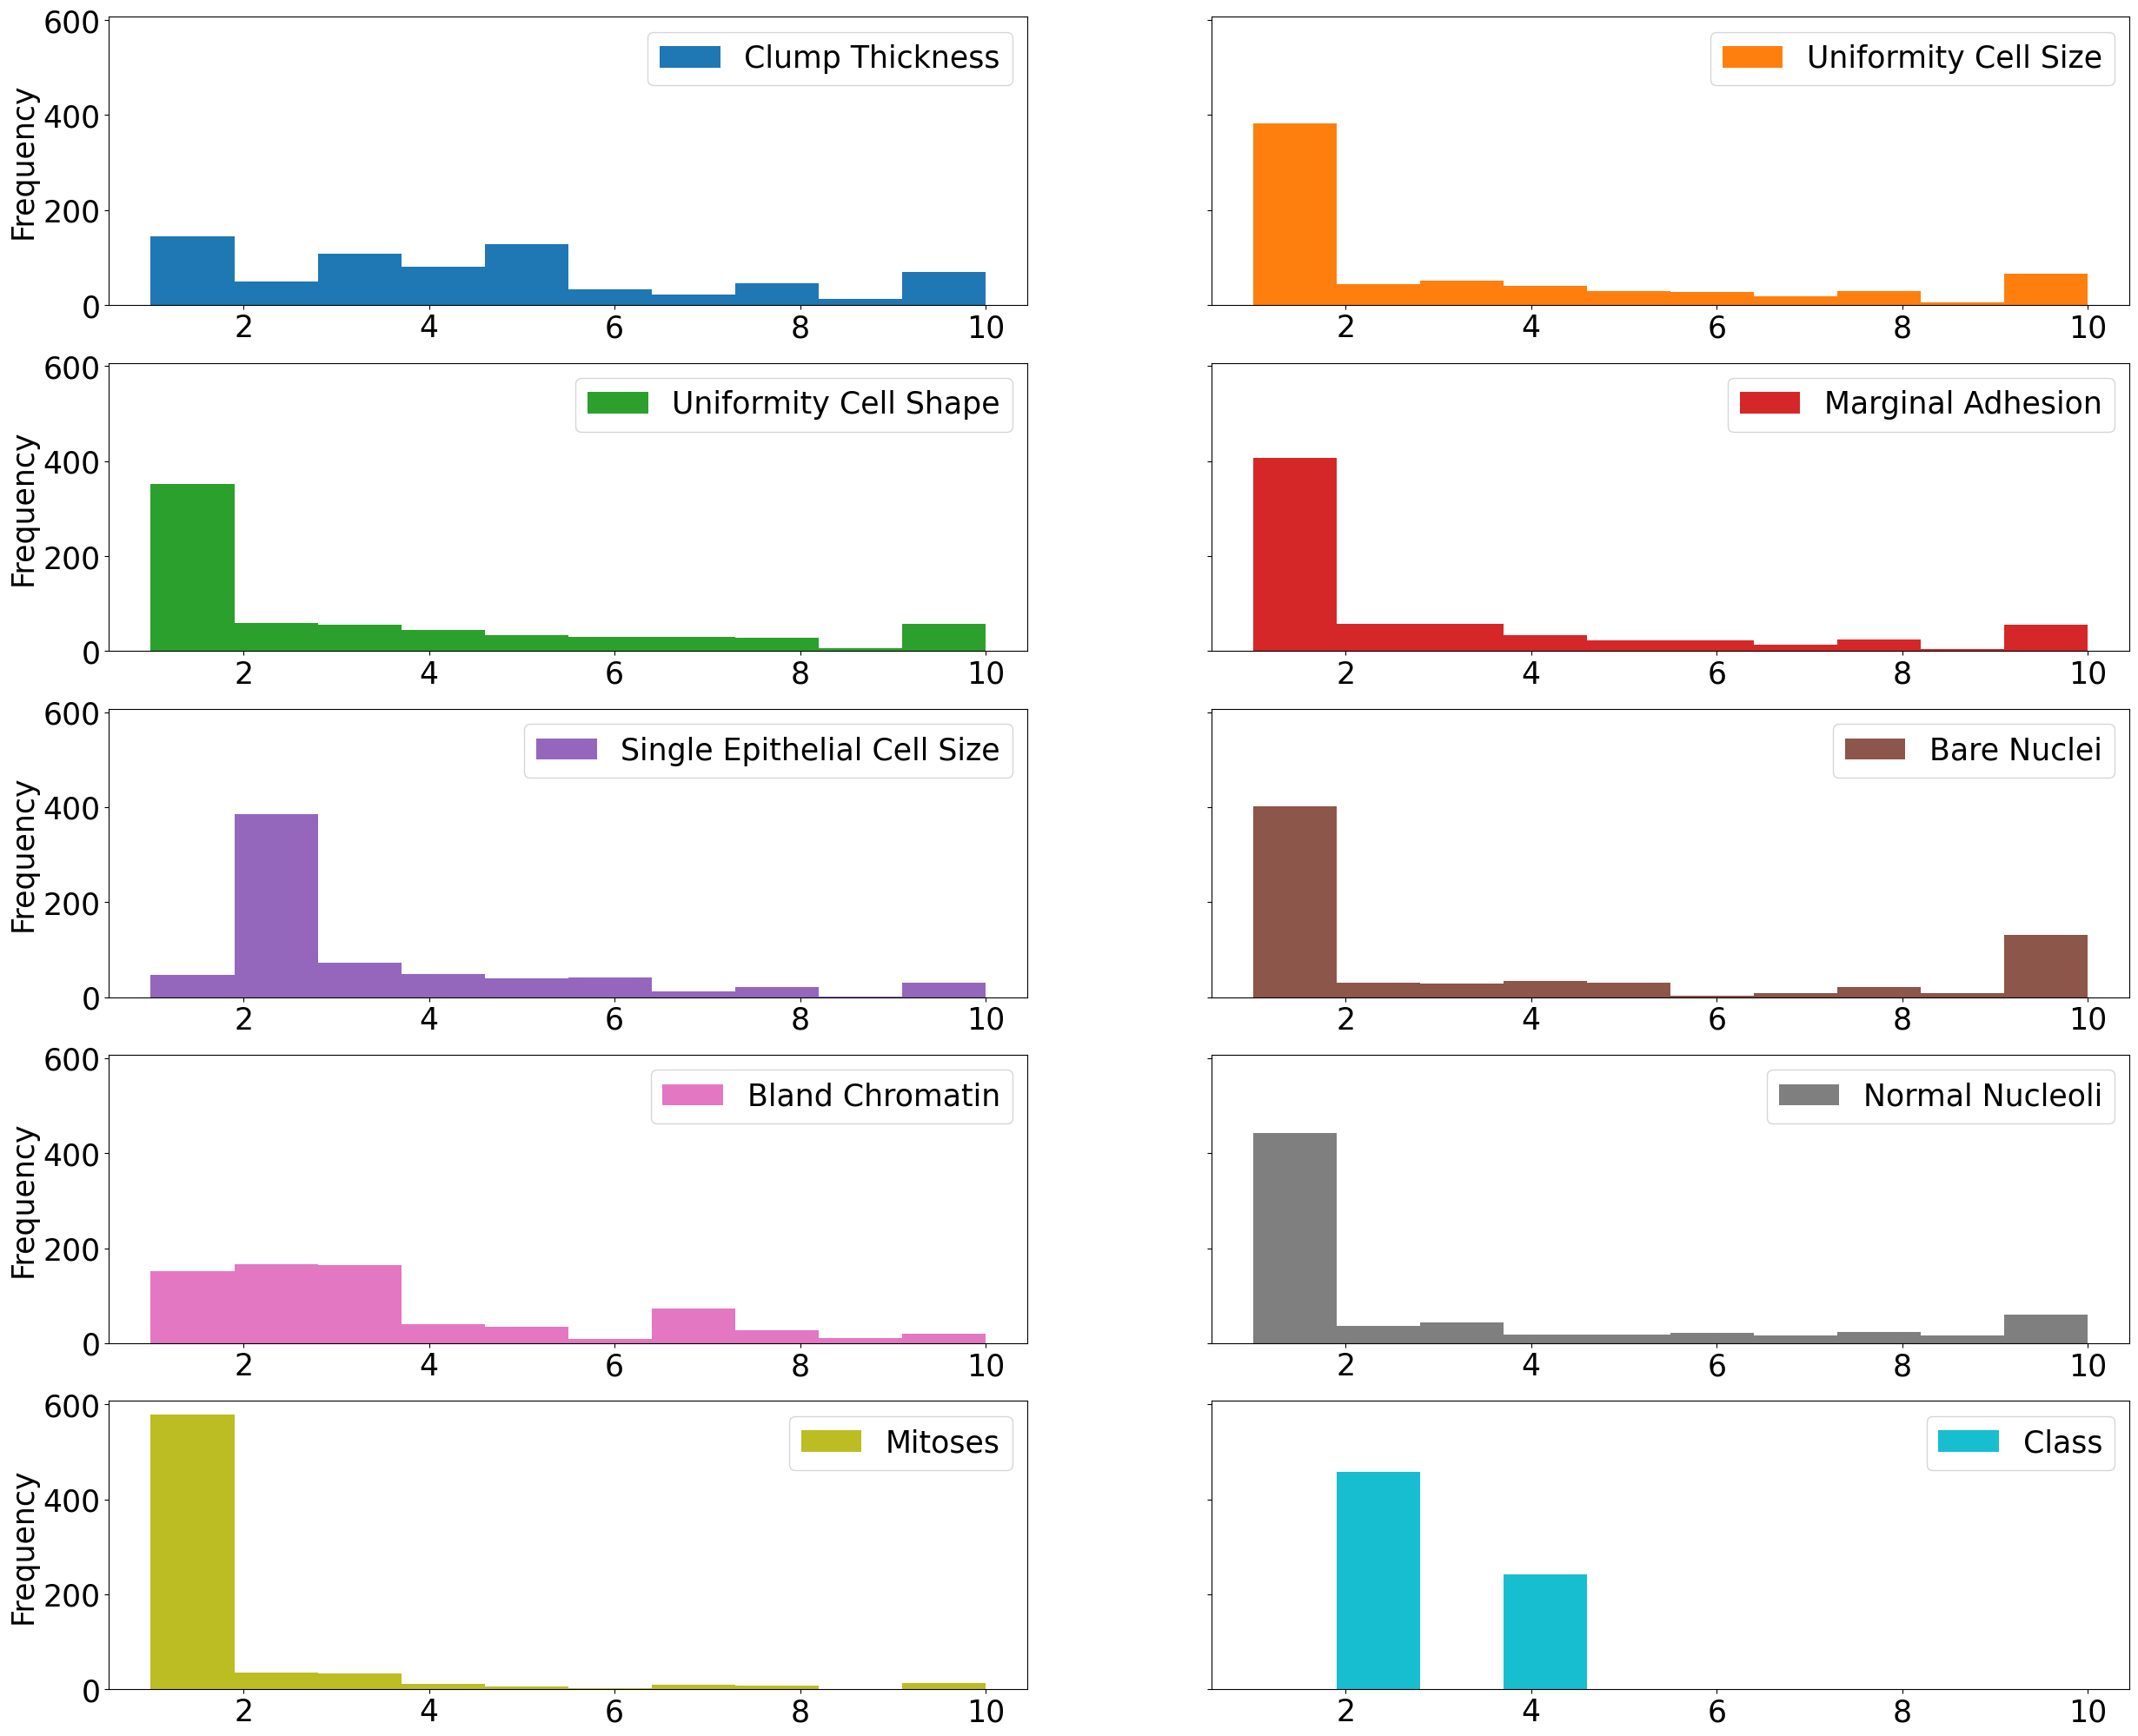

In [ ]:
plt.rcParams.update({'figure.figsize':(30,25),'font.size':25})
data.plot(kind='hist',bins=10,subplots=True,layout=(5,2),sharex=False , sharey = True)
plt.show()

In [ ]:
corelation = data.corr()

In [ ]:
corelation

[Text(0, 0.5, 'Clump Thickness'),
 Text(0, 1.5, 'Uniformity Cell Size'),
 Text(0, 2.5, 'Uniformity Cell Shape'),
 Text(0, 3.5, 'Marginal Adhesion'),
 Text(0, 4.5, 'Single Epithelial Cell Size'),
 Text(0, 5.5, 'Bare Nuclei'),
 Text(0, 6.5, 'Bland Chromatin'),
 Text(0, 7.5, 'Normal Nucleoli'),
 Text(0, 8.5, 'Mitoses'),
 Text(0, 9.5, 'Class')]

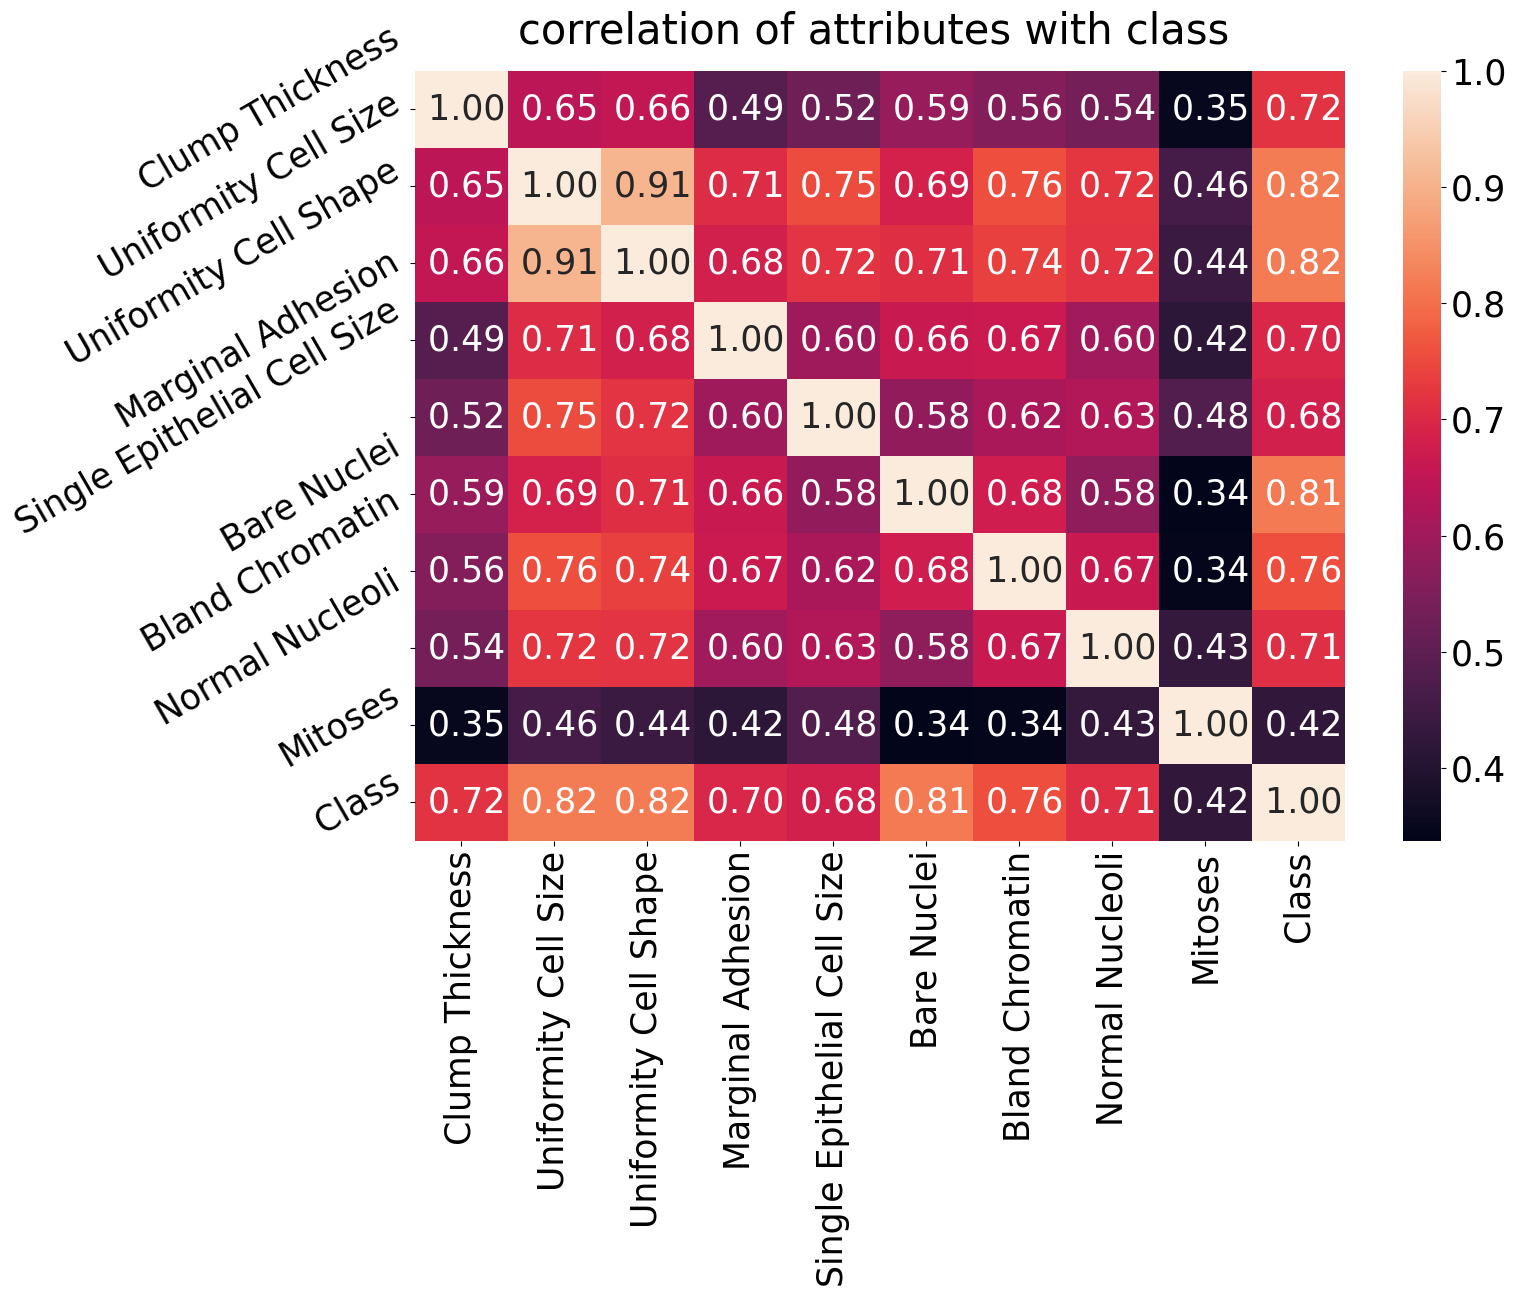

In [ ]:
plt.figure(figsize = (15 , 10))
plt.title('correlation of attributes with class ' , pad = 20)
a = sns.heatmap(corelation , annot = True , fmt = ' .2f')
a.set_xticklabels(data.columns,rotation=90)
a.set_yticklabels(data.columns,rotation=30)

In [ ]:
x = data.drop('Class' , axis = 1)
y = data['Class']

In [ ]:
np.random.seed(43)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
x_train = scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [ ]:
knn=KNeighborsClassifier(n_neighbors=2)

In [ ]:
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=2)

In [ ]:
y_preds=knn.predict(x_test)


In [ ]:
y_preds


array([2, 2, 2, 4, 2, 2, 2, 2, 4, 2, 2, 2, 4, 4, 2, 2, 2, 2, 2, 2, 2, 4,
       2, 4, 2, 2, 4, 4, 2, 2, 2, 4, 4, 4, 2, 2, 2, 2, 2, 4, 4, 2, 4, 2,
       4, 2, 2, 4, 4, 4, 2, 2, 4, 2, 2, 4, 2, 2, 2, 2, 2, 4, 2, 2, 4, 2,
       2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 2, 2, 2, 4, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 2, 4, 2, 4, 2, 4, 2, 2, 2,
       4, 2, 4, 2, 2, 2, 4, 4, 2, 2, 2, 4, 2, 2, 2, 2, 2, 4, 2, 4, 4, 2,
       4, 4, 2, 4, 2, 2, 2, 2])

In [ ]:
knn.predict_proba(x_test)

In [ ]:
confusion_m=confusion_matrix(y_test,y_preds)

Text(75.72222222222221, 0.5, 'Actual Label')

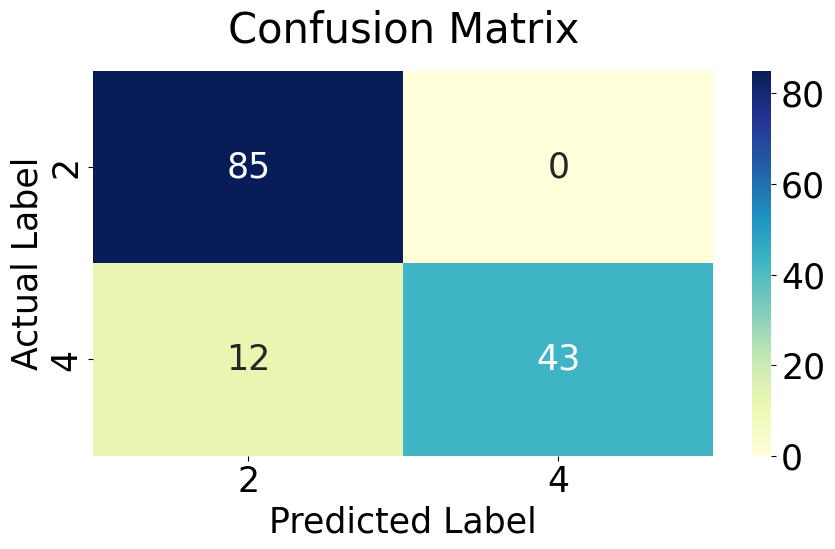

In [ ]:
plt.figure(figsize = (10 , 5))
plt.title('Confusion Matrix' , pad = 20)
c = sns.heatmap(confusion_m , annot =True , cmap="YlGnBu")
c.set_xticklabels([2,4])
c.set_yticklabels([2,4])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')